# 02 · Lateral-growth clusters

Repeat passes of the same RGT are offset laterally, so beams are grouped into **clusters** of passes over the same piece of coast.

For each family, beams are ordered across-track by their position at a common offshore distance `XM` (500 m). Starting from one outer beam (the reference), the cluster grows inward. A candidate beam is added when:

- its profile brackets `X0` (500 m) and `|elev(X0) − elev_ref(X0)| ≤ bias_tolerance`,
- its date is not already in the cluster (same-date beams are skipped, not breakpoints),
- the cluster stays within `SIZE_LIMIT_M` (180 m) of lateral width.

A beam that fails the bias test or the width limit starts the next cluster. Growth runs from both sides; duplicate beam sets are then removed. Clusters need at least `MIN_PROFILES_PER_CLUSTER` (2) beams.

Requires the package installed from the repository root (`pip install -e .`).
Paths come from `configs/north_slope.toml`; all parameters and their defaults are in `src/is2retreat/config.py`.

In [1]:
TRACK_ID = "0129"
CONFIG = "../configs/north_slope.toml"
SOURCE = "auto"
BIAS_TOLERANCE = 0.5   # m

In [2]:
import matplotlib.pyplot as plt

from is2retreat import load_config, prepare_track_inputs
from is2retreat.angles import compute_cluster_angles
from is2retreat.clustering import add_cluster_width_m, make_clusters, select_clusters_per_family
from is2retreat.diagnostics import build_cluster_beam_elevation_check

paths, params = load_config(CONFIG)
inputs = prepare_track_inputs(TRACK_ID, paths, params, source=SOURCE, verbose=False)
dataset_raw, shoreline_gdf, utm_epsg = inputs.dataset_raw, inputs.shoreline_gdf, inputs.utm_epsg
print(f"Track {inputs.track_id}: {dataset_raw['beam_id'].nunique()} beams after preprocessing (notebook 01)")

Track 0129: 73 beams after preprocessing (notebook 01)


## Grow clusters

In [3]:
clusters_gdf, beam_lines = make_clusters(
    dataset_raw,
    utm_epsg=utm_epsg,
    bias_tolerance=BIAS_TOLERANCE,
    xm=params.XM,
    x0=params.X0,
    track_id=inputs.track_id,
    min_beams=params.MIN_PROFILES_PER_CLUSTER,
    size_limit=params.SIZE_LIMIT_M,
)
clusters_gdf[["gt_family", "cluster_id", "growth_side", "reference_beam", "num_beams", "break_reason"]]

,gt_family,cluster_id,growth_side,reference_beam,num_beams,break_reason
0,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,11,bias_breakpoint
1,gt1,2,left,sliderule_0129_gt1l_cyc08_20200703,6,size_limit
2,gt1,3,right,sliderule_0129_gt1l_cyc10_20210101,2,size_limit
3,gt1,4,right,sliderule_0129_gt1l_cyc18_20221229,13,end_of_family
4,gt2,5,left,sliderule_0129_gt2r_cyc23_20240327,4,bias_breakpoint
5,gt2,6,left,sliderule_0129_gt2r_cyc03_20190406,8,bias_breakpoint
6,gt2,7,left,sliderule_0129_gt2l_cyc08_20200703,6,size_limit
7,gt2,8,right,sliderule_0129_gt2l_cyc10_20210101,2,size_limit
8,gt2,9,right,sliderule_0129_gt2l_cyc18_20221229,11,end_of_family
9,gt3,10,left,sliderule_0129_gt3r_cyc11_20210402,4,bias_breakpoint


## Beam/shoreline crossing angles

Angle between each beam and the local shoreline tangent (0–90°). The GIE correction (notebook 03) uses it.

In [4]:
clusters_gdf, beam_angle_table = compute_cluster_angles(
    clusters_gdf, shoreline_gdf, dataset_raw,
    track_id=inputs.track_id, bias_tolerance=BIAS_TOLERANCE,
    mode_bin_width=params.ANGLE_MODE_BIN_WIDTH,
    shoreline_search_radius=params.ANGLE_SEARCH_RADIUS,
)
beam_angle_table.head()

,track_id,bias_tolerance,gt_family,cluster_id,Acq_date,beam_id,beam_angle
0,0129,0.5,gt1,1,2024-03-27,sliderule_0129_gt1r_cyc23_20240327,79.00
1,0129,0.5,gt1,1,2021-04-02,sliderule_0129_gt1r_cyc11_20210402,78.98
2,0129,0.5,gt1,1,2024-12-24,sliderule_0129_gt1r_cyc26_20241224,78.99
3,0129,0.5,gt1,1,2020-01-04,sliderule_0129_gt1r_cyc06_20200104,78.92
4,0129,0.5,gt1,1,2020-04-03,sliderule_0129_gt1r_cyc07_20200403,78.70


## Select clusters and measure their width

In [5]:
selected, skipped, selection_summary = select_clusters_per_family(
    clusters_gdf, min_profiles=params.MIN_PROFILES_PER_CLUSTER, track_id=inputs.track_id
)
selected = add_cluster_width_m(selected, dataset_raw, xm=params.XM, utm_epsg=utm_epsg)
selection_summary

,gt_family,track_id,total_clusters,selected_clusters,skipped_clusters,too_far,cluster_id,angle_deg
0,gt1,0129,4,4,0,0,4,NaN
1,gt2,0129,5,5,0,0,9,NaN
2,gt3,0129,7,5,2,0,14,NaN


In [6]:
selected[["gt_family", "cluster_id", "growth_side", "num_beams", "cluster_width_m",
          "angle_median_deg", "break_reason"]].sort_values(["gt_family", "cluster_id"])

,gt_family,cluster_id,growth_side,num_beams,cluster_width_m,angle_median_deg,break_reason
3,gt1,1,left,11,91.217453,78.97,bias_breakpoint
1,gt1,2,left,6,133.081818,87.32,size_limit
2,gt1,3,right,2,110.545359,87.38,size_limit
0,gt1,4,right,13,133.632967,87.10,end_of_family
8,gt2,5,left,4,32.982726,82.60,bias_breakpoint
5,gt2,6,left,8,83.920842,83.95,bias_breakpoint
6,gt2,7,left,6,134.793780,83.95,size_limit
7,gt2,8,right,2,112.278765,83.90,size_limit
4,gt2,9,right,11,130.504501,83.95,end_of_family
13,gt3,10,left,4,29.710617,83.54,bias_breakpoint


## Elevation at X0 of every member beam

In [7]:
check = build_cluster_beam_elevation_check(dataset_raw, selected, x0=params.X0)
check.head(20)

,gt_family,cluster_id,growth_side,reference_beam,beam_id,beam_order,acq_date,elev_500,is_ref
0,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc23_20240327,1,2024-03-27,3.400575,True
1,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc11_20210402,2,2021-04-02,3.286689,False
2,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc26_20241224,3,2024-12-24,3.159278,False
3,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc06_20200104,4,2020-01-04,3.201242,False
4,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc07_20200403,5,2020-04-03,3.316227,False
5,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc28_20250624,6,2025-06-24,3.143960,False
6,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc03_20190406,7,2019-04-06,3.345782,False
7,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc22_20231227,8,2023-12-27,3.017159,False
8,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc14_20211230,9,2021-12-30,3.311296,False
9,gt1,1,left,sliderule_0129_gt1r_cyc23_20240327,sliderule_0129_gt1r_cyc12_20210702,10,2021-07-02,2.905620,False


## Map

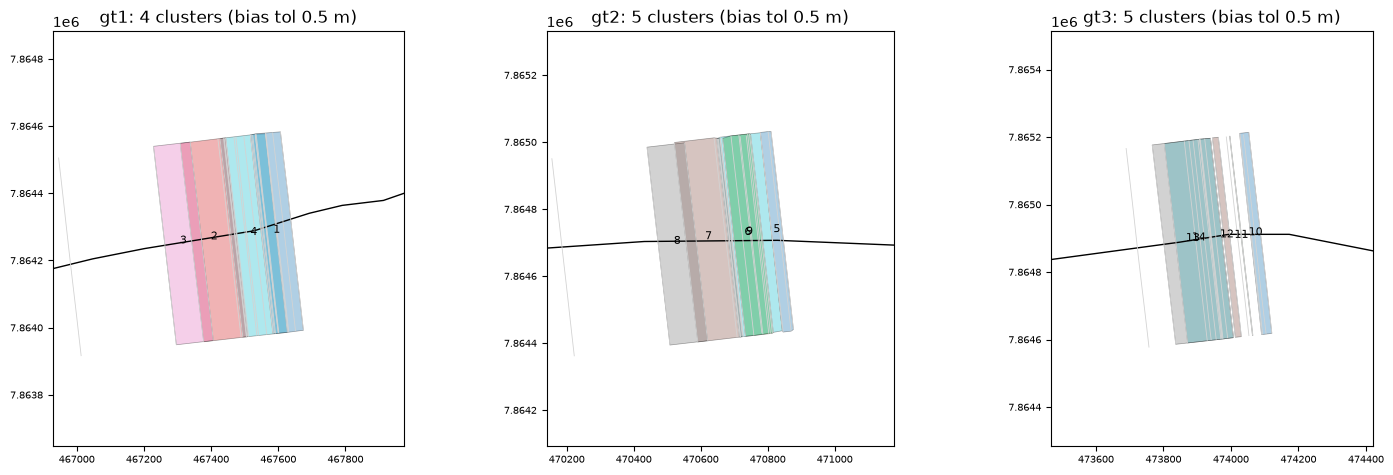

In [8]:
fams = sorted(selected["gt_family"].unique())
fig, axes = plt.subplots(1, len(fams), figsize=(5 * len(fams), 5), squeeze=False)
shoreline_utm = shoreline_gdf.to_crs(utm_epsg)

for ax, fam in zip(axes[0], fams):
    sel = selected[selected["gt_family"] == fam]
    x0_, y0_, x1_, y1_ = sel.total_bounds
    pad = 300
    shoreline_utm.cx[x0_ - pad:x1_ + pad, y0_ - pad:y1_ + pad].plot(ax=ax, color="k", linewidth=1)
    beam_lines[beam_lines["gt_family"] == fam].plot(ax=ax, color="lightgray", linewidth=0.6)
    sel.plot(ax=ax, column="cluster_id", categorical=True, alpha=0.35, edgecolor="k", linewidth=0.5)
    for _, row in sel.iterrows():
        c = row.geometry.centroid
        ax.annotate(str(row["cluster_id"]), (c.x, c.y), fontsize=8, ha="center")
    ax.set_title(f"{fam}: {len(sel)} clusters (bias tol {BIAS_TOLERANCE} m)")
    ax.set_xlim(x0_ - pad, x1_ + pad)
    ax.set_ylim(y0_ - pad, y1_ + pad)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()